# 🧭 Customer Segmentation & Value: Airline Loyalty Program (v1)

**Goal:** go beyond the existing CLV metric and build segments that are *behaviorally* distinct and *actionable* — not just statistically separable clusters.

**Approach (hybrid):**
1. Cluster customers on **behavioral + engagement features only** (flight volume, activity rate, recency, trend, redemption). Demographics and churn probability are deliberately **excluded from the clustering step** — including them would let a categorical variable like card tier or a model-derived churn score distort behavioral cluster boundaries, and would also make the segmentation circular (segments defined partly by the very churn model we're trying to act on).
2. **Overlay** the existing `CLV` and the churn model's `Churn_Probability` on top of the resulting clusters, purely for naming, prioritization, and business storytelling.
3. **Profile** each cluster by demographics (salary, card tier, education) afterward, to see whether demographic traits actually explain behavior — this is itself one of the objectives of the case (interrogating CLV and demographic assumptions).

Input: `Scored_Customers_v2.csv` — the fully scored customer base (12,251 customers) produced in `02_Model_Training_prepared.ipynb`, including `CLV`, `Churn_Probability`, and all engineered behavioral features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Load the scored customer base

In [2]:
df = pd.read_csv('/kaggle/input/datasets/akshita2803/modeling-data-seg/Scored_Customers_v2.csv')
print(df.shape)
df.head(5)


(12251, 35)


,Loyalty Number,Male_Enc,Education_Enc,Marital_Enc,Card_Enc,Salary_Imputed,Salary_Was_Imputed,CLV,Tenure,Promo_Enroll,Total_Flights,Total_Distance,Total_Points_Acc,Total_Points_Red,Avg_Flights_Month,Max_Flights_Month,Active_Months,Activity_Rate,Redemption_Ratio,Avg_Distance_Per_Flight,Months_Since_Last_Flight_at_cutoff,Flights_Q1,Flights_Q2,Flights_Q3,Flights_Q4,Flights_H1,Flights_H2,Flights_Trend,Churn,Formal_Churn,Behavioral_Churn,Never_Flew,Churn_Probability,Churn_Predicted_F1Optimal,Churn_Predicted_RecallFloor
0,480934,0,2,1,0,83236.0,False,3839.14,1,0,18,25352,25352.0,322,1.500000,4,7,0.388887,0.012701,1408.436620,0.0,1.0,8.0,6.0,3.0,9,9,0,0,0,0,0,0.318543,0,0
1,549612,1,1,2,0,73510.0,True,3839.61,1,0,31,36136,36136.0,787,2.583333,5,8,0.258064,0.021779,1165.673659,1.0,10.0,5.0,9.0,7.0,15,16,1,0,0,0,0,0.326320,0,0
2,429460,1,1,0,0,73510.0,True,3839.75,3,0,16,22957,22957.0,374,1.333333,4,7,0.437497,0.016291,1434.803532,1.0,5.0,4.0,5.0,2.0,9,7,-2,1,1,1,0,0.318294,0,0
3,608370,1,1,0,0,73510.0,True,3839.75,4,0,24,33369,33369.0,864,2.000000,5,9,0.374998,0.025892,1390.369207,0.0,8.0,10.0,3.0,3.0,18,6,-12,0,0,0,0,0.319190,0,0
4,530508,1,2,1,0,103495.0,False,3842.79,3,0,11,19886,19886.0,0,0.916667,4,4,0.363633,0.000000,1807.801747,1.0,3.0,2.0,4.0,2.0,5,6,1,0,0,0,0,0.349784,0,0


## 2. Feature engineering for clustering

A few raw columns need cleanup before they're safe to cluster on:

- **`Months_Since_Last_Flight_at_cutoff`** uses a `999` sentinel for customers with zero flights in the feature window. Left as-is, this one value would dominate the distance metric. It's capped at 12 (a year of inactivity reads the same as more).
- **`Redemption_Ratio`** has a handful of extreme outliers (max ≈ 7.3M vs. a 99th percentile of ≈0.11) — almost certainly customers with a near-zero points-accumulated denominator. Winsorized at the 99th percentile.
- **`CLV`** is heavily right-skewed (skew ≈ 2.9). Log-transformed so a handful of very high-CLV customers don't single-handedly define a cluster.


In [3]:
df['Months_Since_Last_Flight_capped'] = df['Months_Since_Last_Flight_at_cutoff'].clip(upper=12)
df['Redemption_Ratio_wz'] = df['Redemption_Ratio'].clip(upper=df['Redemption_Ratio'].quantile(0.99))
df['CLV_log'] = np.log1p(df['CLV'])

CLUSTER_FEATURES = [
    'CLV_log',                          # value
    'Total_Flights',                    # volume
    'Activity_Rate',                    # consistency of flying across active window
    'Months_Since_Last_Flight_capped',  # recency (churn signal, but behavioral not model-derived)
    'Redemption_Ratio_wz',              # engagement with points program
    'Flights_Trend',                    # H2 vs H1 momentum
    'Tenure',                           # years enrolled
]

X = df[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.describe().round(2)


,CLV_log,Total_Flights,Activity_Rate,Months_Since_Last_Flight_capped,Redemption_Ratio_wz,Flights_Trend,Tenure
count,12251.00,12251.00,12251.00,12251.00,12251.00,12251.00,12251.00
mean,8.75,17.39,0.37,1.18,0.02,1.66,2.36
std,0.65,7.96,0.13,2.62,0.02,5.83,1.70
min,7.55,0.00,0.00,0.00,0.00,-22.00,0.00
25%,8.29,13.00,0.32,0.00,0.00,-2.00,1.00
50%,8.66,18.00,0.36,0.00,0.01,2.00,2.00
75%,9.10,23.00,0.42,1.00,0.03,6.00,4.00
max,11.21,61.00,1.00,12.00,0.11,32.00,5.00


## 3. Choosing k

Elbow (inertia) and silhouette score across k=2..8.


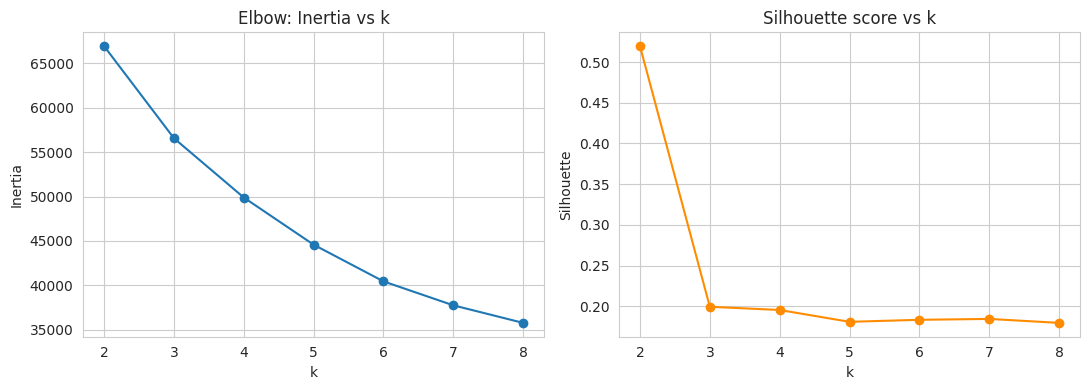

k=2: silhouette=0.5195
k=3: silhouette=0.1993
k=4: silhouette=0.1953
k=5: silhouette=0.1808
k=6: silhouette=0.1833
k=7: silhouette=0.1844
k=8: silhouette=0.1795


In [4]:
inertias, sils, Ks = [], [], range(2, 9)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(Ks), inertias, marker='o')
axes[0].set_title('Elbow: Inertia vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(Ks), sils, marker='o', color='darkorange')
axes[1].set_title('Silhouette score vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

for k, s in zip(Ks, sils):
    print(f"k={k}: silhouette={s:.4f}")


**Reading this:** silhouette peaks at k=2 (≈0.52) then drops and flattens around 0.18–0.19 for k≥3. That's expected, not a red flag — k=2 is simply splitting "flew in the window" vs. "didn't," which is the single largest source of variance but is too coarse to act on (it collapses loyal long-tenured flyers and new ramping members into one bucket).

**k=4** is chosen: inertia gain per additional cluster flattens noticeably after k=4, and four clusters map cleanly onto interpretable, differently-actionable member archetypes (checked below) without over-fragmenting the base into segments too small to build campaigns around.


In [5]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'].value_counts().sort_index()


Cluster
0     589
1    6259
2    3515
3    1888
Name: count, dtype: int64

## 4. Profiling the clusters (behavioral)

In [6]:
profile = df.groupby('Cluster').agg(
    n=('Loyalty Number', 'count'),
    CLV_mean=('CLV', 'mean'),
    Total_Flights_mean=('Total_Flights', 'mean'),
    Activity_Rate_mean=('Activity_Rate', 'mean'),
    Months_Since_Last_mean=('Months_Since_Last_Flight_capped', 'mean'),
    Flights_Trend_mean=('Flights_Trend', 'mean'),
    Redemption_mean=('Redemption_Ratio_wz', 'mean'),
    Tenure_mean=('Tenure', 'mean'),
    Churn_Prob_mean=('Churn_Probability', 'mean'),
    Formal_Churn_rate=('Formal_Churn', 'mean'),
    Behavioral_Churn_rate=('Behavioral_Churn', 'mean'),
    Salary_mean=('Salary_Imputed', 'mean'),
).round(3)
profile['pct_of_base'] = (profile['n'] / len(df) * 100).round(1)
profile


,n,CLV_mean,Total_Flights_mean,Activity_Rate_mean,Months_Since_Last_mean,Flights_Trend_mean,Redemption_mean,Tenure_mean,Churn_Prob_mean,Formal_Churn_rate,Behavioral_Churn_rate,Salary_mean,pct_of_base
Cluster,,,,,,,,,,,,,
0,589,8442.598,0.000,0.000,12.000,0.000,0.001,1.937,0.919,0.092,0.031,76882.136,4.8
1,6259,7984.517,21.531,0.363,0.658,-0.376,0.013,3.295,0.317,0.023,0.020,78860.703,51.1
2,3515,8056.236,14.599,0.399,0.520,5.839,0.008,0.860,0.432,0.063,0.052,77900.756,28.7
3,1888,7495.079,14.263,0.442,0.750,1.160,0.056,2.153,0.379,0.036,0.028,77325.109,15.4


**What falls out of this table:**

- **Cluster 0** (589 customers, 4.8% of base): zero flights in the window, zero activity, recency capped at the max (12 = "no flight in the observation year"). Average model churn probability **0.92** — essentially the model's highest-confidence risk group. Tenure is short-ish (~1.9 yrs). Points redemption is ~0.
- **Cluster 1** (6,259 customers, **51.1%** of base — the largest segment): high flight volume (21.5 avg), most recent activity (0.66 months since last flight), the *longest* average tenure (3.3 yrs), and the *lowest* churn probability (0.32). A slightly negative flight trend (-0.38) is the only soft warning sign here.
- **Cluster 2** (3,515 customers, 28.7%): shortest tenure (0.86 yrs — recently enrolled), and by far the strongest positive flight momentum (+5.84, H2 flights well above H1). Despite the ramp-up, this group carries the *highest* churn probability among active flyers (0.43) and the highest formal/behavioral churn rates in the data.
- **Cluster 3** (1,888 customers, 15.4%): highest activity rate (0.44) and by far the highest points-redemption ratio (0.056 vs. 0.001–0.013 elsewhere) — these are the program's heavy point-redeemers.

**Two things notably do *not* separate the clusters:** `CLV` (7,495–8,443 across all four — a ~13% spread) and `Salary` (76.9k–78.9k, essentially flat), and card-tier mix is nearly identical across clusters too (checked below). That's the case's core question about CLV answered directly: **the current CLV figure carries almost no information about a customer's actual engagement trajectory.** A customer who flew zero times this year (Cluster 0, 92% churn probability) has a CLV *higher* than the loyal, high-flying core (Cluster 1). CLV as currently computed looks backward (historical spend/miles), while churn risk is forward-looking and behavioral — the two need to be looked at *together*, not as substitutes for each other.


In [7]:
demo_check = df.groupby('Cluster')[['Salary_Imputed']].mean().round(0)
demo_check['Card_Enc_mode_share'] = df.groupby('Cluster')['Card_Enc'].agg(lambda x: x.value_counts(normalize=True).max()).round(2)
demo_check['Education_Enc_mode_share'] = df.groupby('Cluster')['Education_Enc'].agg(lambda x: x.value_counts(normalize=True).max()).round(2)
demo_check


,Salary_Imputed,Card_Enc_mode_share,Education_Enc_mode_share
Cluster,,,
0,76882.0,0.43,0.65
1,78861.0,0.46,0.62
2,77901.0,0.46,0.62
3,77325.0,0.47,0.63


**Demographic overlay confirms it:** the modal card tier and modal education level make up almost identical shares of every cluster, and salary is flat. Demographics (card tier, education, salary) are essentially **uncorrelated with behavioral engagement** in this population — a 6-figure-salary Platinum cardholder is just as likely to go dark as anyone else. This matters for the report: it's a defensible reason to **segment on behavior, not demographics**, and a genuine insight a marketing manager looking at a CLV/demographic summary would miss.


## 5. Naming the segments

In [8]:
SEGMENT_NAMES = {
    1: 'Loyal Core',
    3: 'Reward Maximizers',
    2: 'New & Volatile',
    0: 'Gone Dark',
}
df['Segment'] = df['Cluster'].map(SEGMENT_NAMES)
df['Segment'].value_counts()


Segment
Loyal Core           6259
New & Volatile       3515
Reward Maximizers    1888
Gone Dark             589
Name: count, dtype: int64

| Segment | Cluster | Who they are | Why the name |
|---|---|---|---|
| **Loyal Core** | 1 | 51% of the base. High, steady flight volume, longest tenure, lowest churn risk. | The program's backbone — the segment retention efforts should protect, not chase. |
| **Reward Maximizers** | 3 | 15% of the base. Highest activity rate *and* by far the highest points redemption. | They engage with the program specifically through the rewards mechanic — different lever than flight frequency. |
| **New & Volatile** | 2 | 29% of the base. Newest tenure, steepest positive flight momentum, but the highest churn probability of any active-flyer group. | Fast ramp-up doesn't guarantee they stay — enrollment-year engagement patterns aren't predictive of loyalty yet. |
| **Gone Dark** | 0 | 5% of the base. Zero flights, zero activity, 92% average churn probability. | Already effectively churned behaviorally, whether or not they've formally cancelled. |


## 6. CLV × Churn-risk overlay — the priority matrix

In [9]:
df['Risk_Tier'] = pd.cut(
    df['Churn_Probability'], bins=[0, 0.35, 0.5, 1.01],
    labels=['Stable', 'Watch', 'High Risk']
)
df['CLV_Tier'] = pd.qcut(df['CLV'], q=[0, .5, .8, 1.0], labels=['Standard', 'High', 'Top'])

priority = pd.crosstab(df['Segment'], df['Risk_Tier'])
priority


Risk_Tier,Stable,Watch,High Risk
Segment,,,
Gone Dark,0,0,589
Loyal Core,5923,322,14
New & Volatile,1668,784,1063
Reward Maximizers,1212,426,250


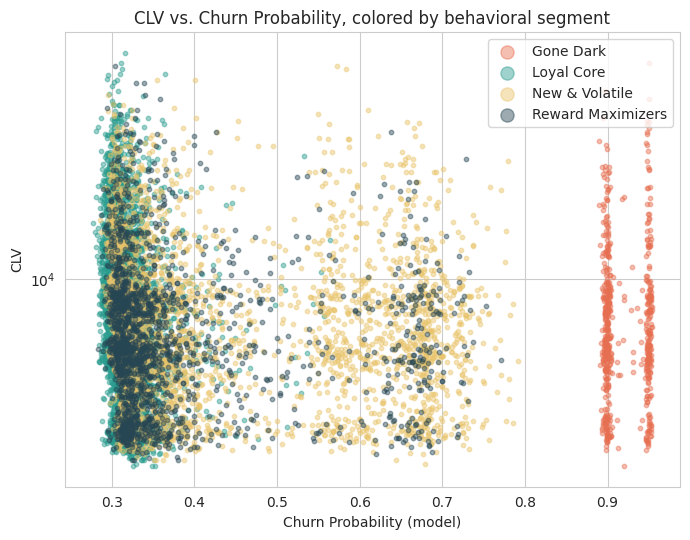

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
palette = {'Loyal Core': '#2a9d8f', 'Reward Maximizers': '#264653',
           'New & Volatile': '#e9c46a', 'Gone Dark': '#e76f51'}
for seg, sub in df.groupby('Segment'):
    ax.scatter(sub['Churn_Probability'], sub['CLV'], s=10, alpha=0.45,
               label=seg, color=palette.get(seg))
ax.set_xlabel('Churn Probability (model)')
ax.set_ylabel('CLV')
ax.set_yscale('log')
ax.set_title('CLV vs. Churn Probability, colored by behavioral segment')
ax.legend(markerscale=3, frameon=True)
plt.tight_layout()
plt.show()


**Reading this scatter:** if CLV and churn risk were redundant, segments would form clean diagonal bands. They don't — high-CLV customers appear scattered across the full churn-probability range in every segment, including **Gone Dark**, which has real value sitting at the top of the CLV axis *and* the top of the churn-risk axis. That combination — high value, high risk — is the actual retention priority list, and CLV alone would never have surfaced it, since Gone Dark's average CLV isn't visibly different from Loyal Core's.


## 7. Segment profile visualization

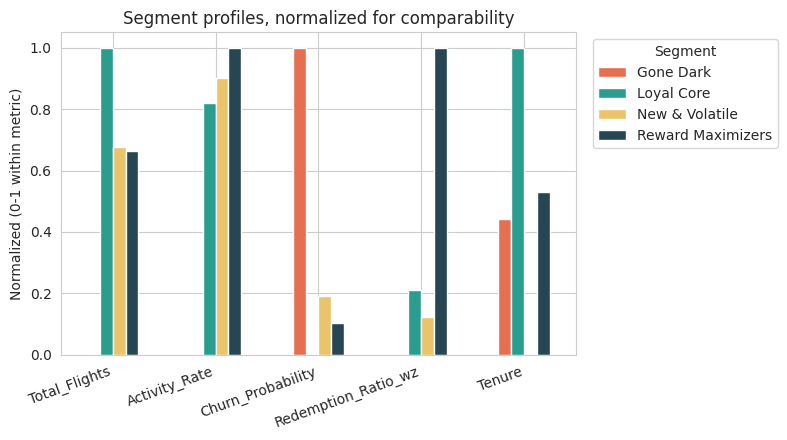

In [11]:
metrics = ['Total_Flights', 'Activity_Rate', 'Churn_Probability', 'Redemption_Ratio_wz', 'Tenure']
radar_df = df.groupby('Segment')[metrics].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

fig, ax = plt.subplots(figsize=(8, 4.5))
radar_norm.T.plot(kind='bar', ax=ax, color=[palette[s] for s in radar_norm.index])
ax.set_ylabel('Normalized (0-1 within metric)')
ax.set_title('Segment profiles, normalized for comparability')
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 8. From segments to action

For each segment: **who** receives the intervention, **when** it fires, **why** (the behavioral trigger), and **what form** it takes — specific enough to hand to an ops team without a follow-up meeting.


| Segment | Trigger (who / when) | Action | Channel & timing | Success metric |
|---|---|---|---|---|
| **Gone Dark** (5%, 92% avg. churn prob.) | Any member with 0 flights in the last 12 months AND still enrolled (not formally cancelled) | Win-back offer: a **status-hold** (freeze tier for 90 days, no re-qualification pressure) + a single-use companion-fare voucher on their historically most-flown route | Personal email + SMS from a named retention agent, sent once, day 1 of detection — not a recurring drip | Reactivation = ≥1 flight booked within 60 days of send |
| **New & Volatile** (29%, highest active-flyer churn risk) | Members in their first enrollment year whose H2 flight count is ≥2x their H1 count (the ramp-up signal) | A **"welcome milestone" call-to-action**: auto-unlock the next tier's lounge/priority-boarding perk temporarily for their next 2 flights, framed as a reward for their fast start, not a retention play | In-app push + email, triggered automatically the week after the 2nd H2 flight | 90-day retention rate of this cohort vs. same cohort last year, tracked in a monthly cohort table |
| **Loyal Core** (51%, lowest risk) | Any member in this segment with a *negative* Flights_Trend (already ~38% of the segment on average) | Light-touch: a personalized "we noticed you're flying less" note bundled with a **relevant** route/fare alert (not a generic points nudge) — protect margin, don't over-invest in a low-risk group | Quarterly email digest, no urgency framing | Segment-level churn rate held flat quarter-over-quarter |
| **Reward Maximizers** (15%, points-driven) | Members whose Redemption_Ratio is in the top quartile of the segment | Partner-brand redemption catalog expansion + early access to redemption sales — engage them on the lever they already use (points), not flight incentives they're less responsive to | In-app catalog notification, monthly cadence | Redemption frequency and partner-catalog click-through rate |


**Why this structure, not a flat "high risk = call them" rule:** churn risk alone tells you *who* is likely to leave, but the segment tells you *why*, which determines whether the fix is a win-back offer, a status perk, or a catalog nudge. Treating New & Volatile the same as Gone Dark would waste a win-back voucher on someone who's actually accelerating, just not loyal yet.


## 9. Export for the prototype / dashboard layer

In [12]:
export_cols = [
    'Loyalty Number', 'Segment', 'Cluster', 'CLV', 'CLV_Tier',
    'Churn_Probability', 'Risk_Tier', 'Formal_Churn', 'Behavioral_Churn', 'Never_Flew',
    'Total_Flights', 'Activity_Rate', 'Flights_Trend', 'Months_Since_Last_Flight_at_cutoff',
    'Redemption_Ratio', 'Tenure', 'Salary_Imputed', 'Card_Enc', 'Education_Enc', 'Marital_Enc',
]
segmented_export = df[export_cols].copy()
segmented_export.to_csv('Segmented_Customers_v1.csv', index=False)
print(f"Saved {len(segmented_export)} rows -> Segmented_Customers_v1.csv")
segmented_export.head()


Saved 12251 rows -> Segmented_Customers_v1.csv


,Loyalty Number,Segment,Cluster,CLV,CLV_Tier,Churn_Probability,Risk_Tier,Formal_Churn,Behavioral_Churn,Never_Flew,Total_Flights,Activity_Rate,Flights_Trend,Months_Since_Last_Flight_at_cutoff,Redemption_Ratio,Tenure,Salary_Imputed,Card_Enc,Education_Enc,Marital_Enc
0,480934,New & Volatile,2,3839.14,Standard,0.318543,Stable,0,0,0,18,0.388887,0,0.0,0.012701,1,83236.0,0,2,1
1,549612,Loyal Core,1,3839.61,Standard,0.326320,Stable,0,0,0,31,0.258064,1,1.0,0.021779,1,73510.0,0,1,2
2,429460,Loyal Core,1,3839.75,Standard,0.318294,Stable,1,1,0,16,0.437497,-2,1.0,0.016291,3,73510.0,0,1,0
3,608370,Loyal Core,1,3839.75,Standard,0.319190,Stable,0,0,0,24,0.374998,-12,0.0,0.025892,4,73510.0,0,1,0
4,530508,Loyal Core,1,3842.79,Standard,0.349784,Stable,0,0,0,11,0.363633,1,1.0,0.000000,3,103495.0,0,2,1


**Next step:** this file (`Segmented_Customers_v1.csv`) is the input for the Streamlit/Power BI prototype — segment, risk tier, and CLV tier are all pre-computed so the front end just needs to filter, not recompute anything, keeping it fast for a non-technical user.
